In [2]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys

import scipy
import numpy as np
import pandas as pd
import nibabel as nb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")
import precision_mapping as pm
import xmath_tools as xmt
import CAP_tools

sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# Create Cifti List 

In [3]:
cifti_dir = "/home/cole/_research/data/HCP_7T_ciftis"
cifti_dir = "/Users/cole/_tmp/"

cifti_paths = sorted(glob.glob(f"{cifti_dir}/*REST*.dtseries.nii"))
subjects = [path.split("--", maxsplit=3)[1] for path in cifti_paths]

example_cifti = nb.load(cifti_paths[0])

### Load vFC Correlation Results

In [4]:
results_dir = "/data/data7/network_control/results/HCP_7T_analysis/vFC_corr_results"

vFC_corr_paths = glob.glob(f"{results_dir}/*vFC_corr.npy")
vFC_corr_paths = [p for p in vFC_corr_paths if "-ec" not in p]

vFC_corr = {}
for p in tqdm(vFC_corr_paths):
    vFC_corr[p.split("/")[-1].split("_")[0]] = np.load(p)
vFC_corr_arr = np.vstack(list(vFC_corr.values()))
result_subj_pairs = np.array([k.split("-") for k in vFC_corr.keys()])

  0%|          | 0/1227 [00:00<?, ?it/s]

### load relationship labels

In [5]:
hcp_behav_df_path = "/Users/cole/Downloads/RESTRICTED_HCP_behavioral_data.csv"

hcp_behav_df = pd.read_csv(hcp_behav_df_path)
hcp_behav_df.columns = [col.lower() for col in hcp_behav_df.columns]
hcp_behav_df["subject"] = hcp_behav_df["subject"].astype(str)
hcp_behav_df = hcp_behav_df.loc[hcp_behav_df["subject"].isin(subjects)]

r_labels = []
for p in result_subj_pairs:
    pdf = hcp_behav_df.loc[hcp_behav_df["subject"].isin(p)]
    rlabel = pdf["zygositysr"].iloc[0] if len(pdf["family_id"].unique()) == 1 else "unrelated"
    r_labels.append(rlabel)

r_labels = np.array(r_labels)

# Examples of Relationship RS-vFC Comparisons

In [6]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

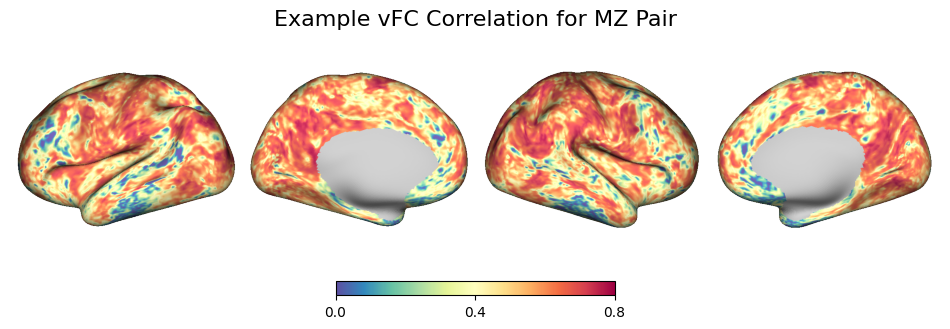

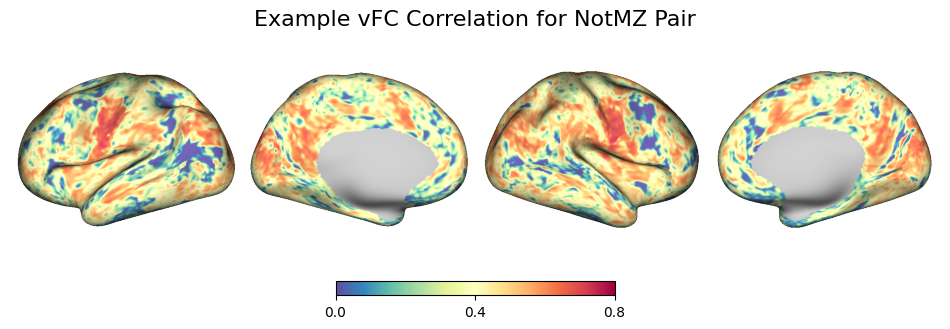

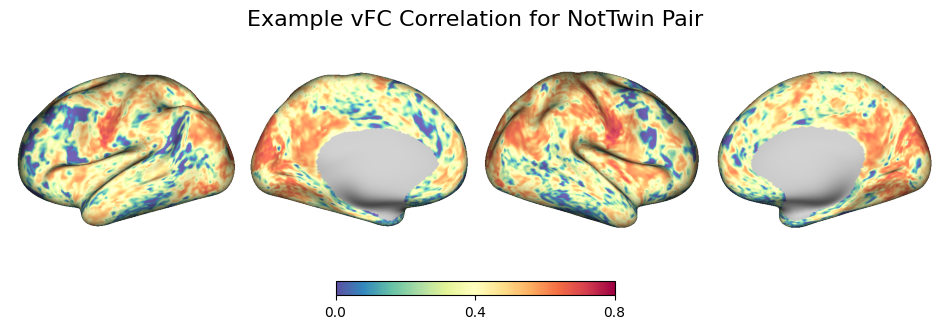

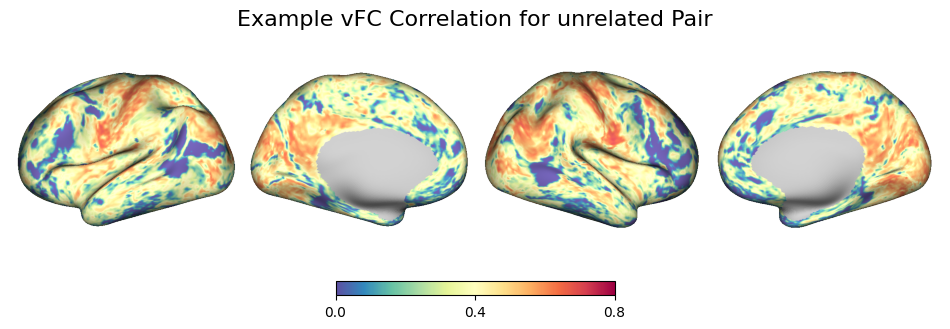

In [18]:
for rlabel in np.unique(r_labels):
    vs = vFC_corr_arr[np.where(r_labels == rlabel)[0][0]]
    vs = np.clip(vs, 0, 0.8)
    vs[:2] = [0, 0.8]
    ax, _ = vertex_plot(vs, example_cifti, cmap=plt.cm.Spectral_r)
    ax.set_title(f"Example vFC Correlation for {rlabel} Pair", fontsize=16);

# Relationship vFC Comparisons

Text(0.5, 0.9, 'Mean vFC Corr by Family Status')

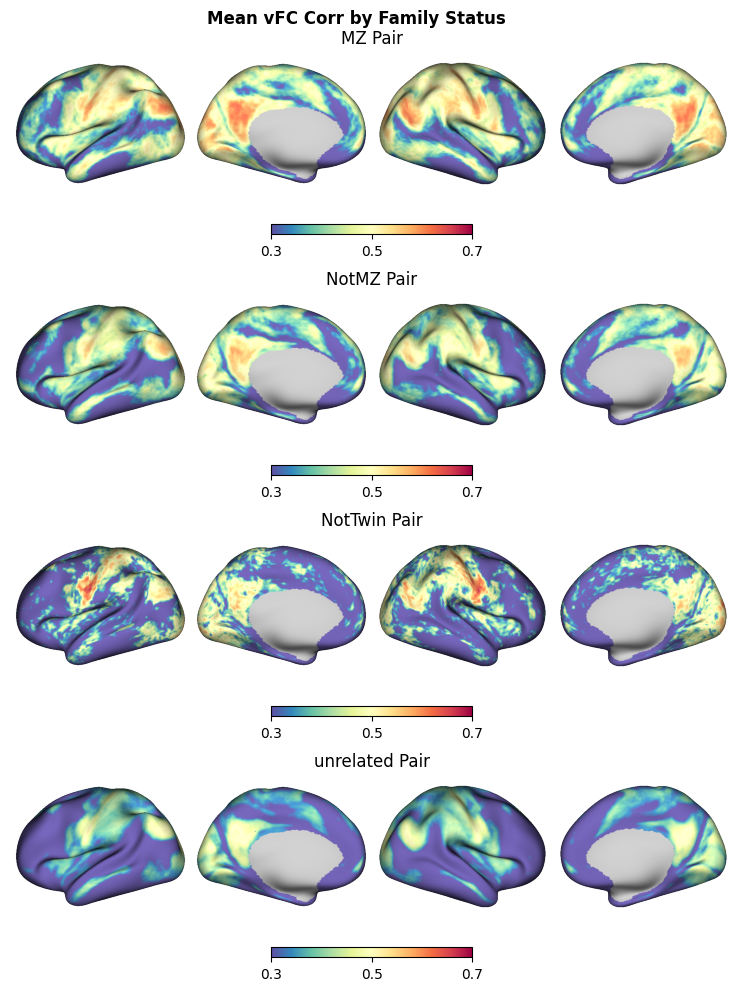

In [26]:
# fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
# fig.tight_layout(h_pad=-10)
axes = axes.ravel()
for ax, rlabel in zip(axes, np.unique(r_labels)):
    vs = vFC_corr_arr[r_labels == rlabel]
    vs = np.mean(vs, axis=0)
    vs = np.clip(vs, .3, .7)
    vs[:2] = [0.3, 0.7]
    # ax, _ = vertex_plot(vs, example_cifti, cmap=plt.cm.viridis, views="lh", cbar=False, ax=ax)
    ax, _ = vertex_plot(vs, example_cifti, cmap=plt.cm.Spectral_r, cbar=True, ax=ax)
    ax.set_title(f"{rlabel} Pair", y=0.9);
fig.suptitle("Mean vFC Corr by Family Status", fontweight="heavy", y=0.9)

MZ
NotMZ


Context leak detected, msgtracer returned -1


NotTwin


Text(0.5, 1.0, 'vFC Corr Comparison to Unrelated (T-Statistic)')

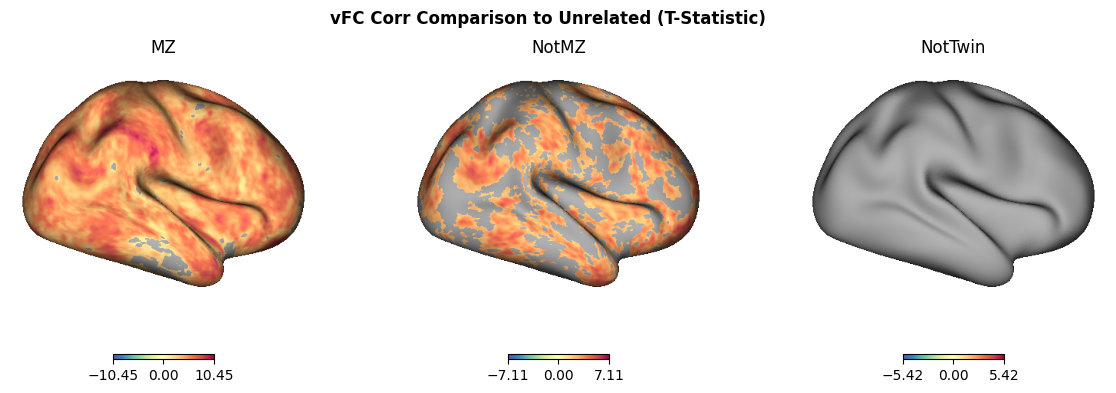

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.tight_layout()
axes = axes.ravel()
i = 0
for rlabel in np.unique(r_labels):
    if rlabel == "unrelated":
        continue

    print(rlabel)
    t_s, p_s = scipy.stats.ttest_ind(vFC_corr_arr[r_labels == rlabel], vFC_corr_arr[r_labels == "unrelated"])
    q_s = scipy.stats.false_discovery_control(p_s)
    t_s[q_s >= 0.05] = np.nan
    # t_s[q_s >= 0.05] = t_s[q_s >= 0.05] * 0.05
    
    ax, _ = vertex_plot(t_s, example_cifti, cmap=plt.cm.Spectral_r, views="rh", ax=axes[i])
    ax.set_title(rlabel, y=0.9)
    i += 1

fig.suptitle("vFC Corr Comparison to Unrelated (T-Statistic)", y=1.0, fontweight="heavy")

Text(0.5, 1.0, 'vFC Corr Monozygotic to Dizygotic (T-Statistic)')

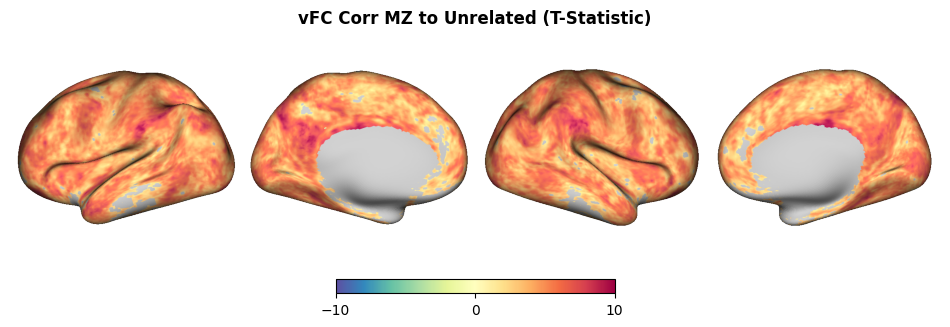

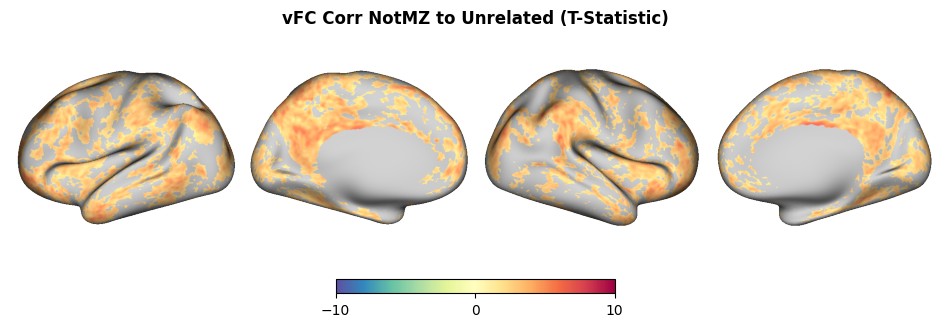

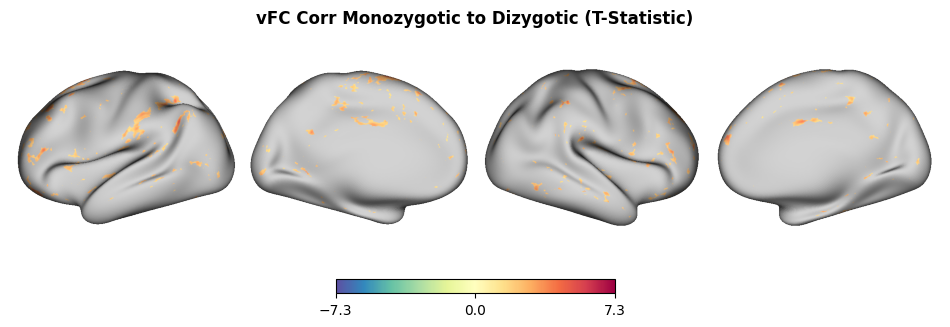

In [46]:
for family_label in ["MZ", "NotMZ"]:
    
    t_s, p_s = scipy.stats.ttest_ind(vFC_corr_arr[r_labels == family_label], vFC_corr_arr[r_labels == "unrelated"])
    q_s = scipy.stats.false_discovery_control(p_s)
    t_s[q_s >= 0.05] = np.nan

    t_s = np.clip(t_s, -10, 10)
    t_s[:2] = [-10, 10]
    
    ax, _ = vertex_plot(t_s, example_cifti, cmap=plt.cm.Spectral_r)
    ax.set_title(f"vFC Corr {family_label} to Unrelated (T-Statistic)", y=1.0, fontweight="heavy")


t_s, p_s = scipy.stats.ttest_ind(vFC_corr_arr[r_labels == "MZ"], vFC_corr_arr[r_labels == "NotTwin"])
q_s = scipy.stats.false_discovery_control(p_s)
t_s[p_s >= 0.05] = np.nan

# t_s = np.clip(t_s, -3, 3)
t_s[:2] = [-3, 3]

ax, _ = vertex_plot(t_s, example_cifti, cmap=plt.cm.Spectral_r)
ax.set_title(f"vFC Corr Monozygotic to Dizygotic (T-Statistic)", y=1.0, fontweight="heavy")